# 2. The spatial scale of interactions

Notebook 01 asked whether two cell types are close *on average*. That collapses geometry
to one number per cell type pair. Here we keep the distance axis and ask at **which
distances** an interaction is enriched.

Two related statistics do this:

**Cross-PCF** (cross pair-correlation function) measures whether two cell types occur near
one another more or less frequently than expected at given distances.
<br>

**LRIC** (Ligand–Receptor Interaction Correlation) extends this idea by incorporating
ligand and receptor expression. Rather than counting every neighbouring cell pair equally,
it weights **sender cells by ligand expression** and **receiver cells by receptor
expression**.

<img src="LRIC_summary.png" width=1200 />

## Interpreting cross-PCF and LRIC results

Both methods return a distance-dependent statistic, `g(r)`, calculated for spatial distance
bins centred around a given distance (r).
<br>

g(r) > 1 indicates enrichment at distance r. <br>
g(r) ≈ 1 indicates no enrichment beyond the null expectation. <br>
g(r) < 1 indicates depletion or spatial avoidance.

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

import liana as li

import warnings
warnings.filterwarnings("ignore")

adata = sc.read_h5ad("data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layer

In [2]:
## Set variables
cell_type_key = "cell_type"
spatial_key = "X_spatial_coords"

resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")

3989 LR pairs in resource


## Choose the right parameters
All distance parameters are in the same units as the spatial coordinates — **µm** for this
MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of
the diameter of generic cells; though this might vary a lot depending on the tissue and
cell types!). <br>
**annulus_steps** = width of each annulus ring, counted in `radius_step`s (so the ring
width is `annulus_steps * radius_step`). <br>
The default `annulus_steps = 1` gives non-overlapping bins that tile the full range
without gaps. Setting `annulus_steps > 1` makes consecutive annuli overlap — a moving
window over the same tiles — which smooths `g(r)` at the cost of correlating neighbouring
bins. <br>
**max_radius** = inner edge of the last (widest) bin; the outer edge extends to
`max_radius + annulus_steps * radius_step`.

In [3]:
radius_step = 20

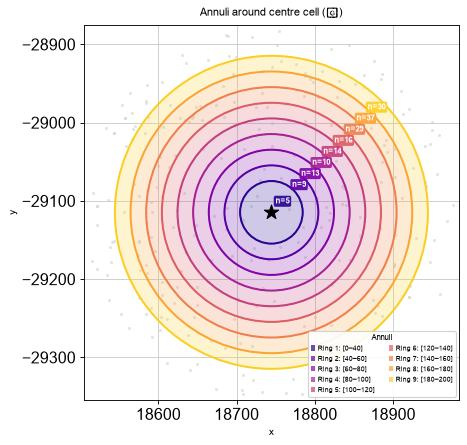

In [4]:
li.pl.annulus(
    adata,
    spatial_key="X_spatial_coords",
    radius_step=radius_step,
    n_rings=9,
    seed=5,
    figure_size= (6, 6),
    return_fig=False)

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)`
contact band is merged **into the first annulus**, which therefore spans
`[0, (1 + annulus_steps) * radius_step)` and starts at radius 0. Distances are measured
from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell
diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging
it folds genuine cell–cell contact pairs into the first bin instead of discarding them.
Set `extend_first_annulus=False` to keep the first ring at
`[radius_step, (1 + annulus_steps) * radius_step)`.

## Ranking interactions using the AUC–log2 score

`g(r)` is a curve per interaction. To compare many interactions, we apply the **AUC-log2
score**: the mean area under `log2 g(r)`.

- **`log2`** puts enrichment and depletion on one symmetric axis: `0` = null,
  `+1` = 2× enriched, `−1` = 2× depleted.
- **Integrate over radius.** The score is the area under `log2 g(r)`,

$$\text{score} = \frac{1}{\Delta r}\int \log_2 g(r)\,dr$$

Integrating (rather than taking the peak) makes the score reflect the *whole* curve: a
pair that is consistently enriched across radii accumulates a large area, while a single
noisy bin contributes only a thin sliver. Dividing by the radial span `Δr` turns the area
into a **mean log2 fold-change**. By default the integral is taken over a **short-range
window** (`max_dist`).

`li.mt.get_lric_auc` returns one row per interaction with the same id columns as the
result it summarises (`source`/`target`/`ligand_complex`/`receptor_complex`/`interaction`)
plus `score`, sorted most-enriched first — so it drops straight into `li.pl.dotplot`.

**Read it as:** `> 0` co-enriched, `< 0` depleted, `≈ 0` random. The magnitude is a
fold-change (`2**score`, so `1` ≈ 2×).

## Cross-PCF

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected if cell-type labels were randomly shuffled across the same observed cell locations?

It treats all cells **equally**. Gene expression is not considered. We use it to
characterise the raw spatial architecture of the tissue before asking about LR
interactions.

In [5]:
li.mt.cross_pcf(
    adata,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    min_cells= None,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!
Computing cross-PCF over 11 retained cell types (55 pairs emitted).


In [6]:
## Explore the output: one row per cell-type pair x radius bin
adata.uns["cross_pcf"].head()

,source,target,interaction,radius,g
0,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,0.0,0.861141
1,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,40.0,0.905863
2,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,60.0,0.934052
3,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,80.0,0.979085
4,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,100.0,0.994321


### Aggregation: cells cluster together at a short distance

**Choroid plexus epithelial cells** and **ependymal cells** show strong spatial enrichment,
consistent with their anatomical continuity along the ventricular surface. Choroid plexus
epithelium is a specialised ventricular epithelium that meets the ependymal lining at
choroid plexus attachment and transition zones.

In [7]:
# rank short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
cross_pcf_res = li.mt.get_lric_auc(adata, "cross_pcf", max_dist=50, min_bins=2)
print(cross_pcf_res.head(3).to_string(index=False))

                        source                       target                                                 interaction    score  peak_radius
choroid plexus epithelial cell               ependymal cell               choroid plexus epithelial cell^ependymal cell 3.752287         40.0
choroid plexus epithelial cell vascular leptomeningeal cell choroid plexus epithelial cell^vascular leptomeningeal cell 2.576310         40.0
choroid plexus epithelial cell                     pericyte                     choroid plexus epithelial cell^pericyte 1.306699         40.0


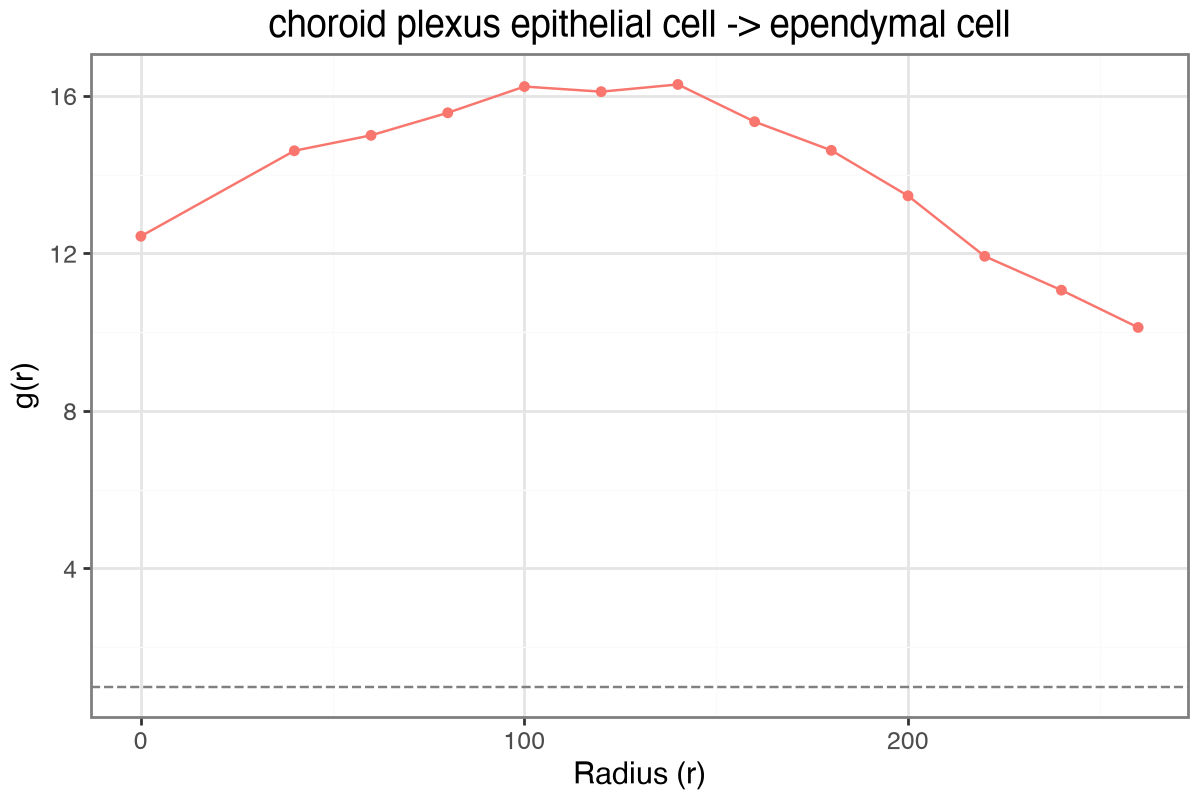

In [8]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="ependymal cell")

### Exclusion: cells occupy distinct anatomical compartments

**Choroid plexus epithelial cells** are confined to the choroid plexus at the ventricular
interface, whereas **glutamatergic neurons** are distributed throughout the surrounding
brain parenchyma. Their strong depletion, with `g(r)<1`, indicates fewer cross-type
neighbours than expected and primarily reflects spatial compartmentalisation rather than
direct cellular repulsion.

In [9]:
print(cross_pcf_res.tail(3).to_string(index=False))

                        source                         target                                                   interaction     score  peak_radius
choroid plexus epithelial cell           glutamatergic neuron           choroid plexus epithelial cell^glutamatergic neuron -3.116759          0.0
choroid plexus epithelial cell                oligodendrocyte                choroid plexus epithelial cell^oligodendrocyte -3.207982          0.0
choroid plexus epithelial cell oligodendrocyte precursor cell choroid plexus epithelial cell^oligodendrocyte precursor cell -3.836286          0.0


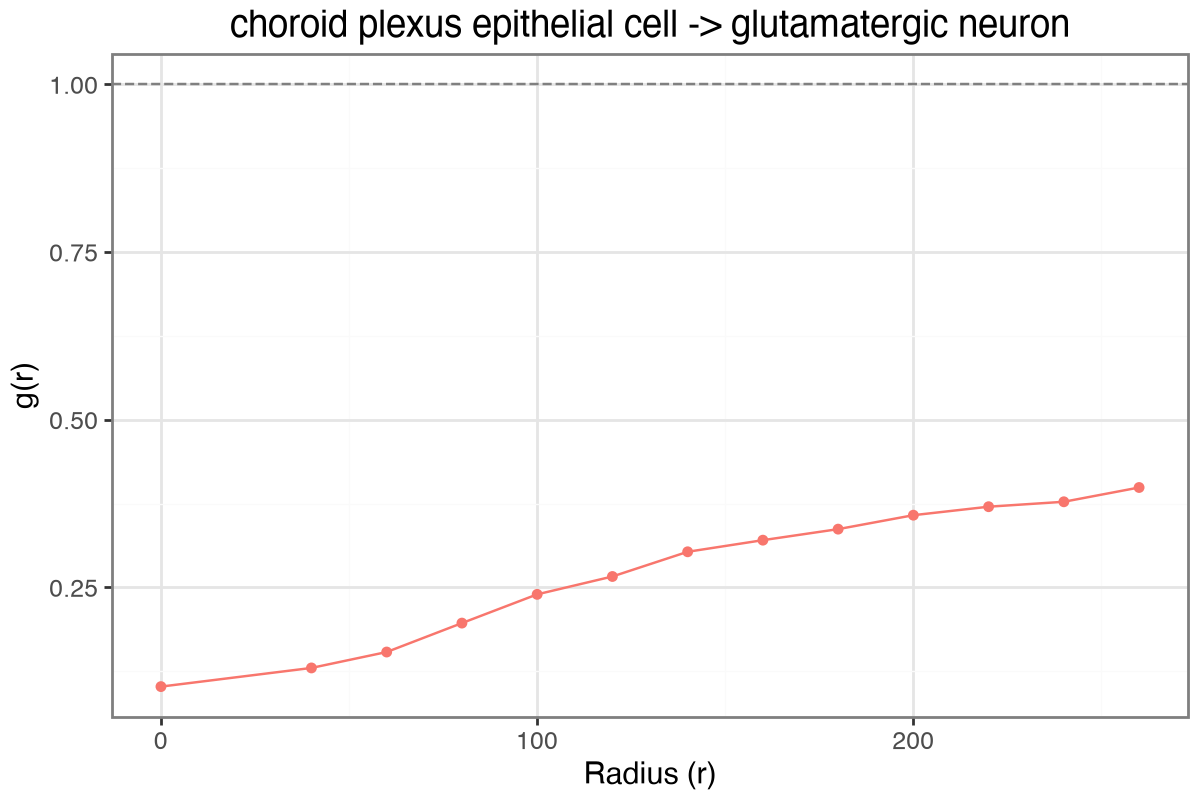

In [10]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="glutamatergic neuron")

## LRIC: cell-type informed, directed interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by
cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair,
weighted by LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only be
driven by cells that express the relevant ligand/receptor.

In [11]:
li.mt.lric(
    adata,
    resource=resource,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    expr_prop=0.2,  # NaN-mask sender/receiver-celltype pairs expressed in <20% of that celltype
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!
0.85 of entities in the resource are missing from the data.
Running LRIC (conditional within-type null) over 11 retained cell types (110 directed pairs emitted).
LRIC: 100%|██████████| 110/110 [00:00<00:00, 207.34it/s]


Using provided `resource`.


In [12]:
# short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
lric_ct_res = li.mt.get_lric_auc(adata, "lric_ct", max_dist=50, min_bins=2)
print(lric_ct_res.head(3).to_string(index=False))

                        source                         target ligand_complex receptor_complex  interaction    score  peak_radius
  vascular leptomeningeal cell choroid plexus epithelial cell        Col18a1             Gpc4 Col18a1^Gpc4 3.896360         40.0
choroid plexus epithelial cell                 ependymal cell        Sostdc1             Lrp4 Sostdc1^Lrp4 3.759548         40.0
choroid plexus epithelial cell                 ependymal cell        Col18a1             Gpc4 Col18a1^Gpc4 3.735166         40.0


The AUC ranking uses liana's own column names, so it feeds straight into
`li.pl.dotplot`. Rather than mapping the same score twice, colour shows the **magnitude**
(AUC-log2) while dot size shows `peak_radius` — the radius at which each interaction
deviates most from the null. With `inverse_size=True`, bigger dots mean tighter,
shorter-range coupling.

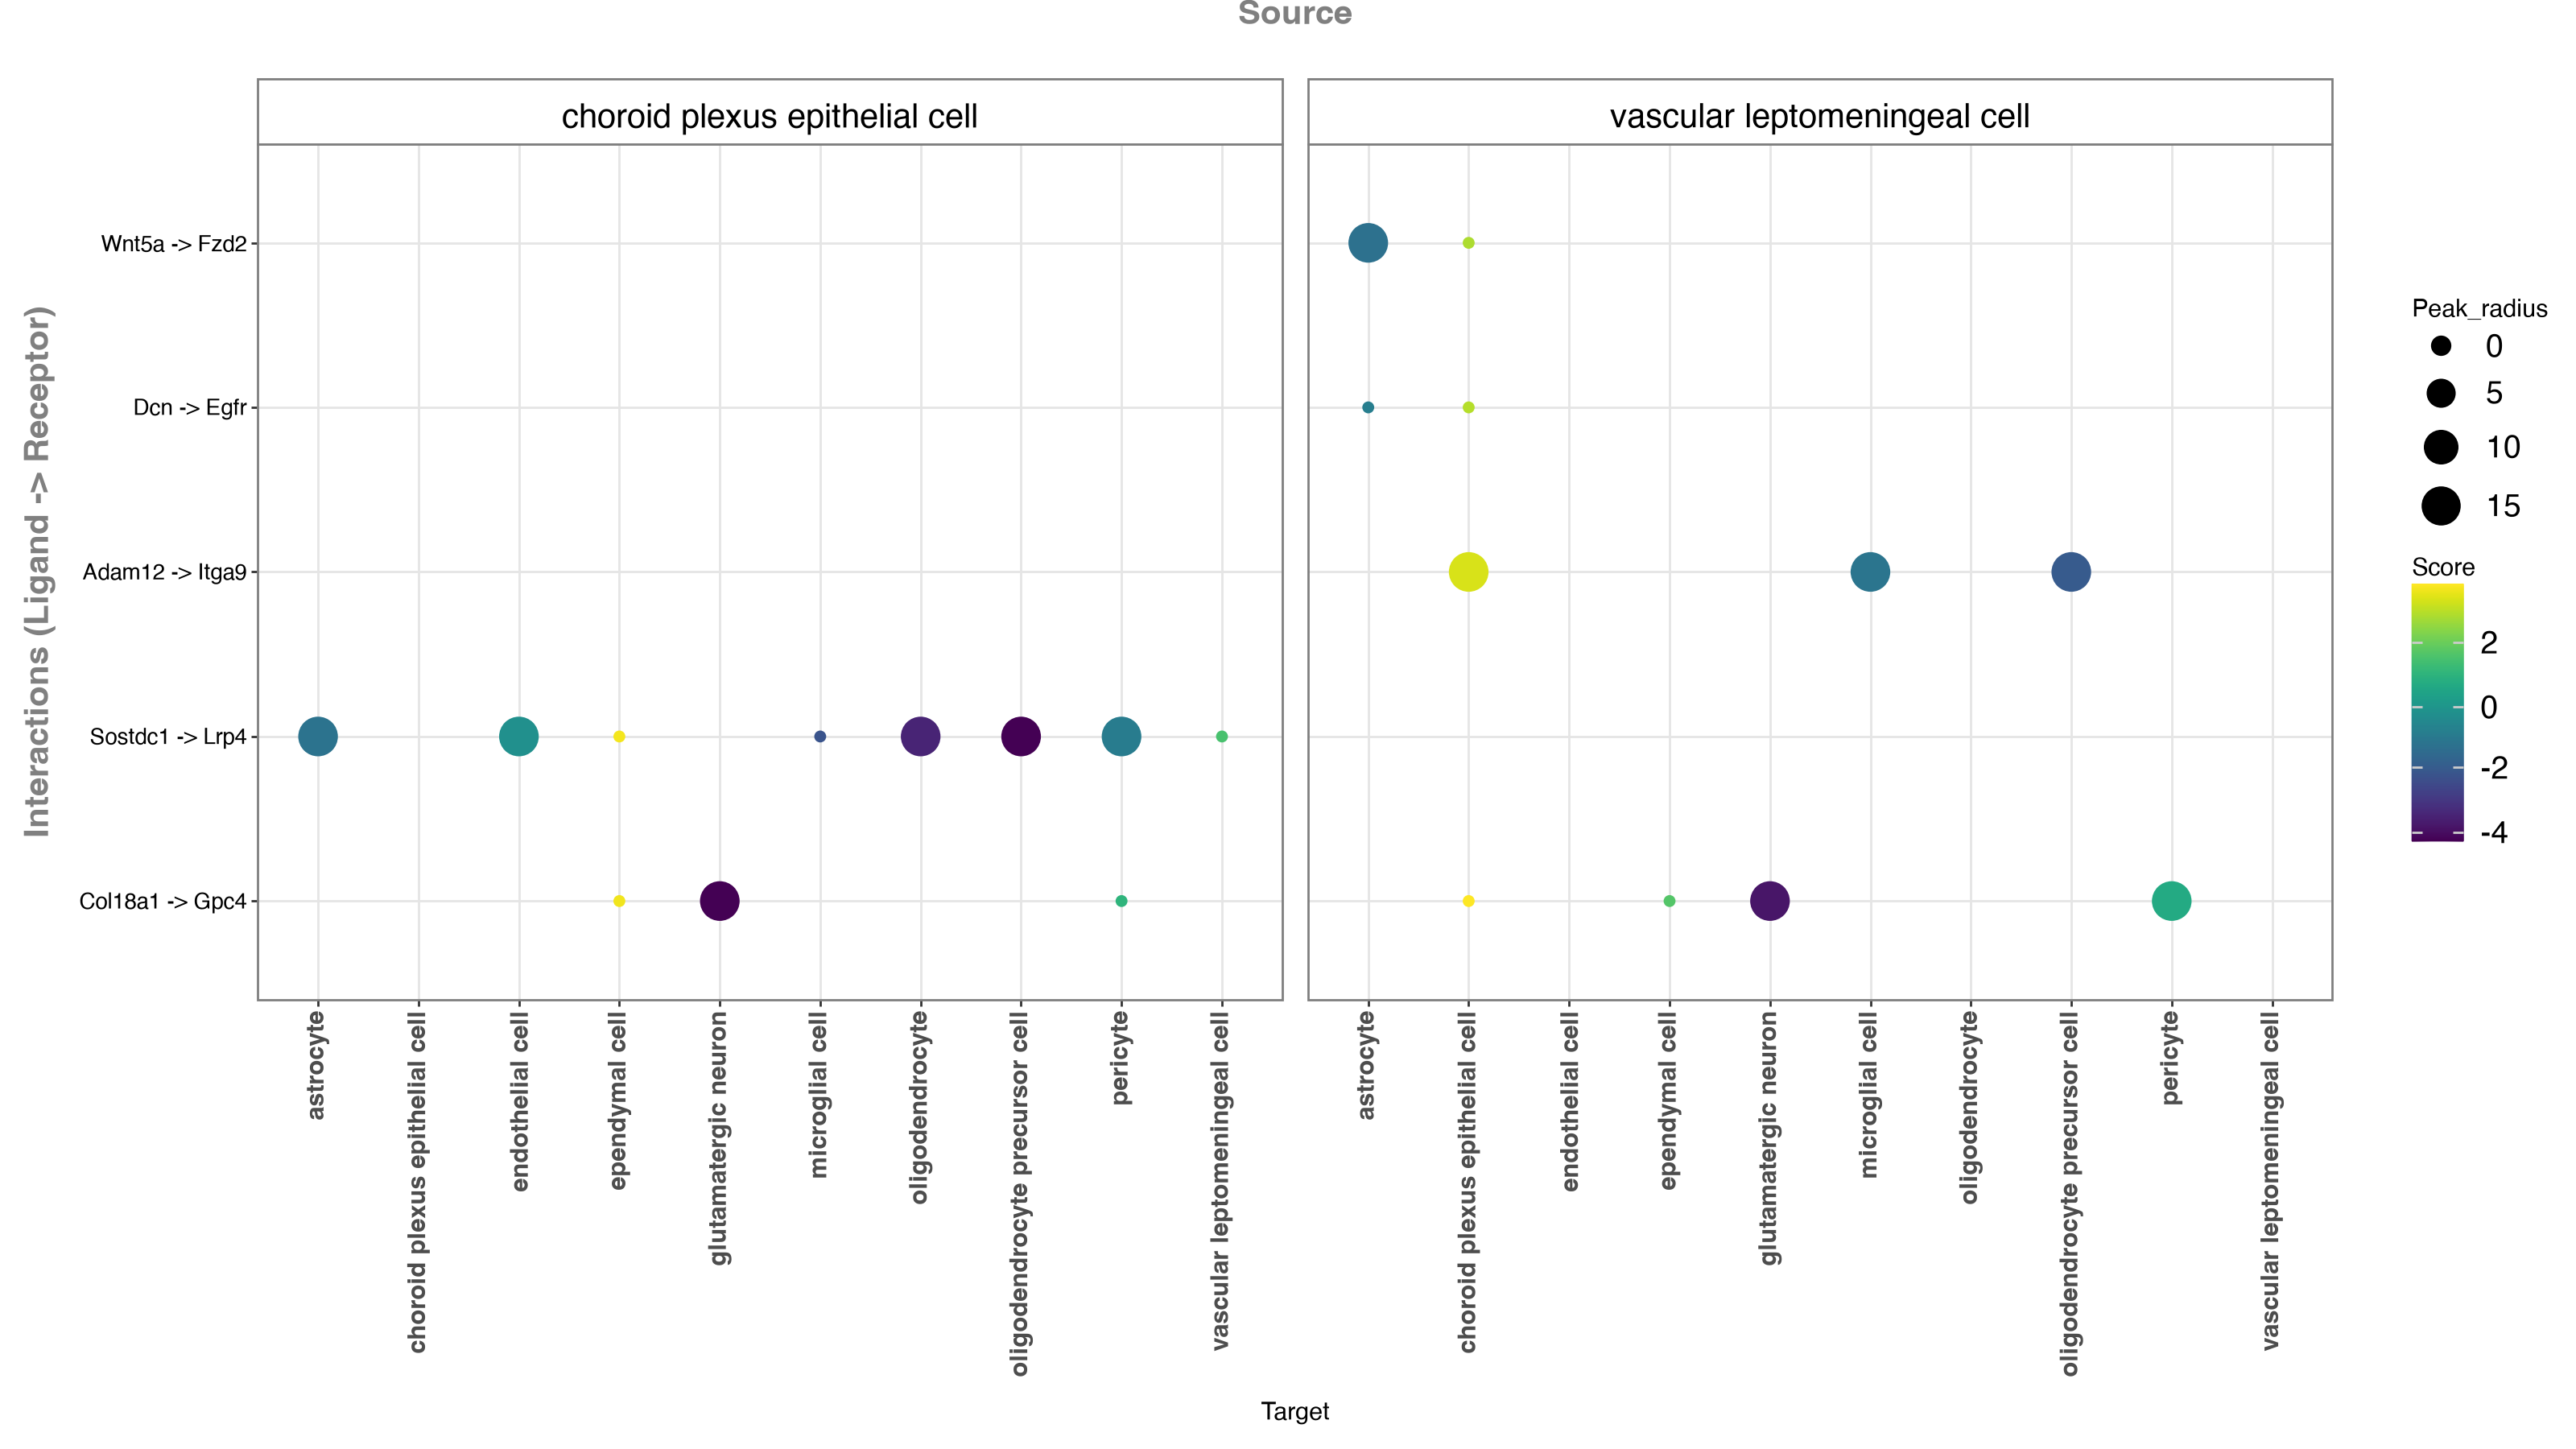

In [13]:
li.pl.dotplot(
    liana_res=lric_ct_res,
    colour="score", size="peak_radius", inverse_size=True,
    orderby="score",
    orderby_ascending=False, top_n=5,
    figure_size=(16, 9),
    source_labels=['vascular leptomeningeal cell', 'choroid plexus epithelial cell']
)

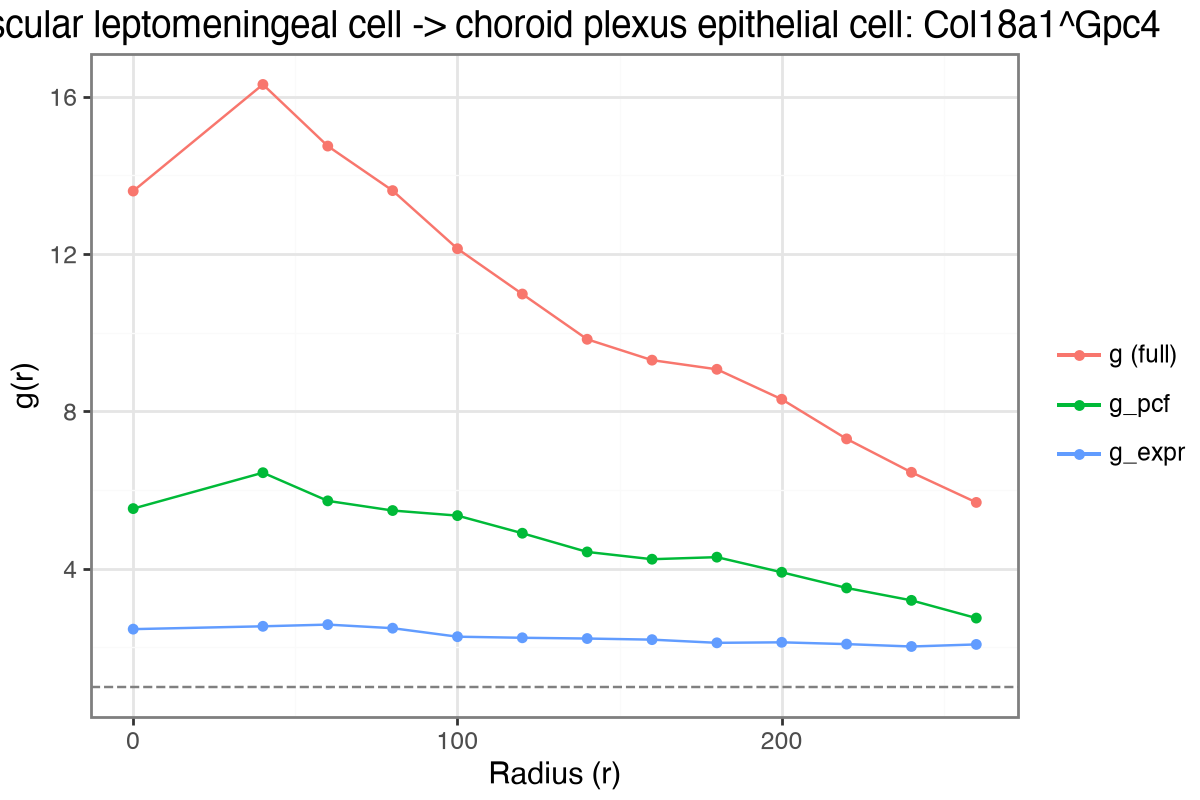

In [14]:
li.pl.lric_lineplot(adata, "lric_ct",
                    source="vascular leptomeningeal cell",
                    target="choroid plexus epithelial cell",
                    interaction="Col18a1^Gpc4")

**Col18a1 $\rightarrow$ Gpc4** from **vascular leptomeningeal cells $\rightarrow$ choroid
plexus epithelial cells** shows the strongest cell-type-informed spatial enrichment, with
$g_{\mathrm{full}}(r)$ peaking at approximately **16.3 around $40\,\mu\mathrm{m}$**.

The underlying cell-type organisation is already strongly enriched
($g_{\mathrm{pcf}} \approx 6.4$), reflecting the close spatial association of vascular
leptomeningeal and choroid plexus epithelial cells. Ligand–receptor expression provides an
additional enrichment component ($g_{\mathrm{expr}} \approx 2.5$), amplifying the full
signal beyond that explained by cell-type proximity alone.

Thus, the interaction is supported by both anatomical co-localisation and non-random
**Col18a1/Gpc4** expression within the respective sender and receiver populations.

---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — Does the scale depend on the binning?**

`radius_step` sets how finely distance is binned, and `max_radius` how far out we look.
Both are choices, not measurements.

Re-run `li.mt.cross_pcf` with `radius_step=10` and `radius_step=40` (keep `max_radius=250`),
then compare the `peak_radius` reported by `li.mt.get_lric_auc` for the choroid plexus
epithelial → ependymal pair.

Does the detected scale survive a change of binning?
</div>

In [15]:
for step in [10, 20, 40]:
    li.mt.cross_pcf(adata, groupby=cell_type_key, spatial_key=spatial_key,
                    max_radius=250, radius_step=step, min_cells=None,
                    key_added=f"pcf_{step}", verbose=False)
    # ... pull out the choroid plexus -> ependymal row and look at score / peak_radius
    print(step)

10
20
40


<details>
<summary><b>▶ Solution</b></summary>

```python
for step in [10, 20, 40]:
    li.mt.cross_pcf(adata, groupby=cell_type_key, spatial_key=spatial_key,
                    max_radius=250, radius_step=step, min_cells=None,
                    key_added=f"pcf_{step}", verbose=False)
    res = li.mt.get_lric_auc(adata, f"pcf_{step}", max_dist=50, min_bins=2)
    row = res[(res["source"] == "choroid plexus epithelial cell") &
              (res["target"] == "ependymal cell")]
    print(f"radius_step={step:>3} µm | score={row['score'].iloc[0]:.3f} "
          f"| peak_radius={row['peak_radius'].iloc[0]}")
```

The *qualitative* answer is stable — this pair is short-range enriched at every binning.
The *numbers* are not: `peak_radius` can only ever be a multiple of `radius_step`, so a
coarse binning cannot resolve a peak more precisely than its own bin width, and
`max_dist=50` contains a different number of bins in each case (`min_bins=2` is what
stops a single bin from being integrated).

The practical lesson: report the binning alongside any claim about "the scale" of an
interaction, and choose `radius_step` from the biology (roughly a cell diameter) rather
than from the data.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick a different interaction from `lric_ct_res` — or a different cell type pair from
`cross_pcf_res` — and plot its curve with `li.pl.lric_lineplot`.

Is it enriched (g > 1) or depleted (g < 1)? Over what range of distances? And does the
`g_expr` component tell you the expression is adding anything, or is the signal purely
cell-type architecture?
</div>

In [16]:
# your turn
lric_ct_res.head(20)

,source,target,ligand_complex,receptor_complex,interaction,score,peak_radius
0,vascular leptomeningeal cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1^Gpc4,3.896360,40.0
1,choroid plexus epithelial cell,ependymal cell,Sostdc1,Lrp4,Sostdc1^Lrp4,3.759548,40.0
2,choroid plexus epithelial cell,ependymal cell,Col18a1,Gpc4,Col18a1^Gpc4,3.735166,40.0
3,vascular leptomeningeal cell,choroid plexus epithelial cell,Adam12,Itga9,Adam12^Itga9,3.412289,0.0
4,ependymal cell,choroid plexus epithelial cell,Fgf1,Egfr,Fgf1^Egfr,3.386779,40.0
5,vascular leptomeningeal cell,choroid plexus epithelial cell,Dcn,Egfr,Dcn^Egfr,2.973550,40.0
6,vascular leptomeningeal cell,choroid plexus epithelial cell,Wnt5a,Fzd2,Wnt5a^Fzd2,2.893658,40.0
7,choroid plexus epithelial cell,vascular leptomeningeal cell,Sfrp1,Fzd2,Sfrp1^Fzd2,2.402296,40.0
8,vascular leptomeningeal cell,ependymal cell,Col18a1,Gpc4,Col18a1^Gpc4,1.695779,40.0
9,choroid plexus epithelial cell,vascular leptomeningeal cell,Sostdc1,Lrp4,Sostdc1^Lrp4,1.517685,40.0


<details>
<summary><b>▶ Solution</b></summary>

Any row works; the interesting comparison is between the components the line plot shows.

`g_full ≈ g_pcf × g_expr`. When `g_expr ≈ 1`, the interaction is enriched only because the
two cell types sit next to each other — LRIC is telling you nothing that cross-PCF did not
already say. When `g_expr` is clearly above 1 (as for `Col18a1^Gpc4`, ≈ 2.5), the ligand-
and receptor-expressing subsets are *additionally* concentrated towards each other beyond
what cell-type architecture explains. Those are the interactions worth following up.

Also note what is missing: `lric` emits no self-pairs, so an interaction within a single
cell type will not appear in this table at all.

</details>

---

**Next:** notebook 03 drops the summary statistics entirely and asks where in the tissue,
cell by cell, an interaction is happening.